In [1]:
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')

matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

In [2]:
df=pd.read_csv(r"C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\final project 3\XAU_1d_data.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,2004.06.11 00:00,384.0,384.8,382.8,384.1,272
1,2004.06.14 00:00,384.3,385.8,381.8,382.8,1902
2,2004.06.15 00:00,382.8,388.8,381.1,388.6,1951
3,2004.06.16 00:00,387.1,389.8,382.6,383.8,2014
4,2004.06.17 00:00,383.6,389.3,383.0,387.6,1568


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
df = df.sort_values('Date')

In [5]:
df.set_index('Date', inplace=True)

In [6]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2004-06-11,384.0,384.8,382.8,384.1,272
2004-06-14,384.3,385.8,381.8,382.8,1902
2004-06-15,382.8,388.8,381.1,388.6,1951
2004-06-16,387.1,389.8,382.6,383.8,2014
2004-06-17,383.6,389.3,383.0,387.6,1568


In [7]:
df.shape

(5516, 5)

In [8]:
df.describe()

,Open,High,Low,Close,Volume
count,5516.000000,5516.000000,5516.000000,5516.000000,5.516000e+03
mean,1405.246032,1415.762846,1394.620100,1405.606541,8.501507e+04
std,651.083760,656.464934,646.052608,651.689418,1.023805e+05
min,382.800000,384.800000,381.100000,382.800000,2.000000e+00
25%,1063.335000,1071.165000,1053.015000,1062.400000,2.647400e+04
50%,1299.545000,1307.060000,1291.715000,1299.920000,7.270800e+04
75%,1744.107500,1755.182500,1728.527500,1743.532500,1.122268e+05
max,4538.000000,4550.160000,4483.010000,4531.170000,1.401078e+06


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5516 entries, 2004-06-11 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5516 non-null   float64
 1   High    5516 non-null   float64
 2   Low     5516 non-null   float64
 3   Close   5516 non-null   float64
 4   Volume  5516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 258.6 KB


In [13]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [14]:
df.index.min(), df.index.max()

(Timestamp('2004-06-11 00:00:00'), Timestamp('2025-12-31 00:00:00'))

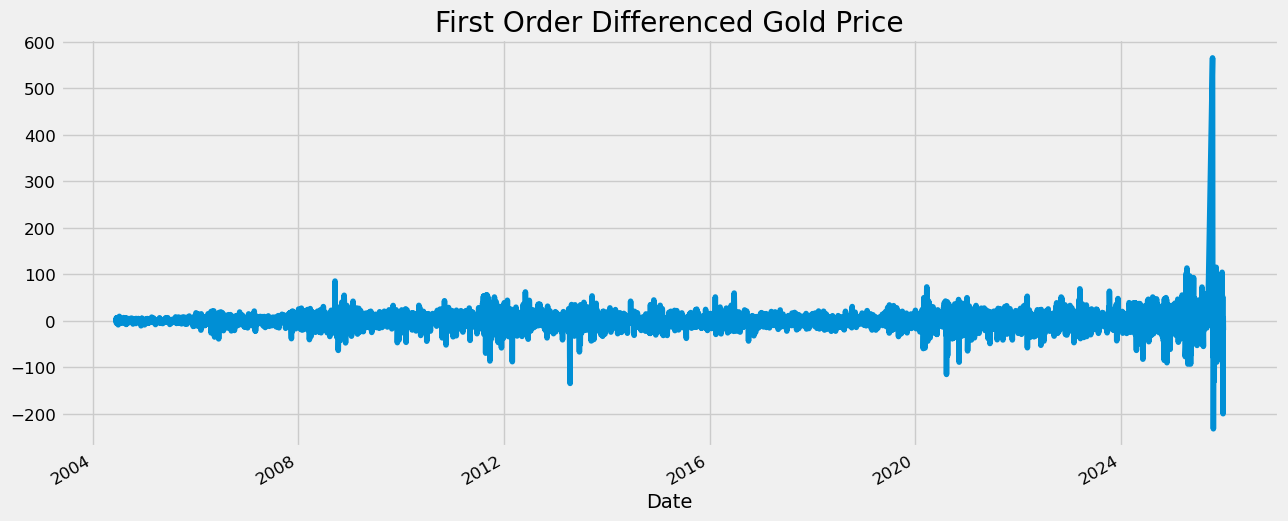

In [15]:
#first order differencing
df_diff = df['Close'].diff().dropna()

plt.figure(figsize=(14,6))
df_diff.plot()
plt.title("First Order Differenced Gold Price")
plt.show()

In [16]:
y = df['Close']


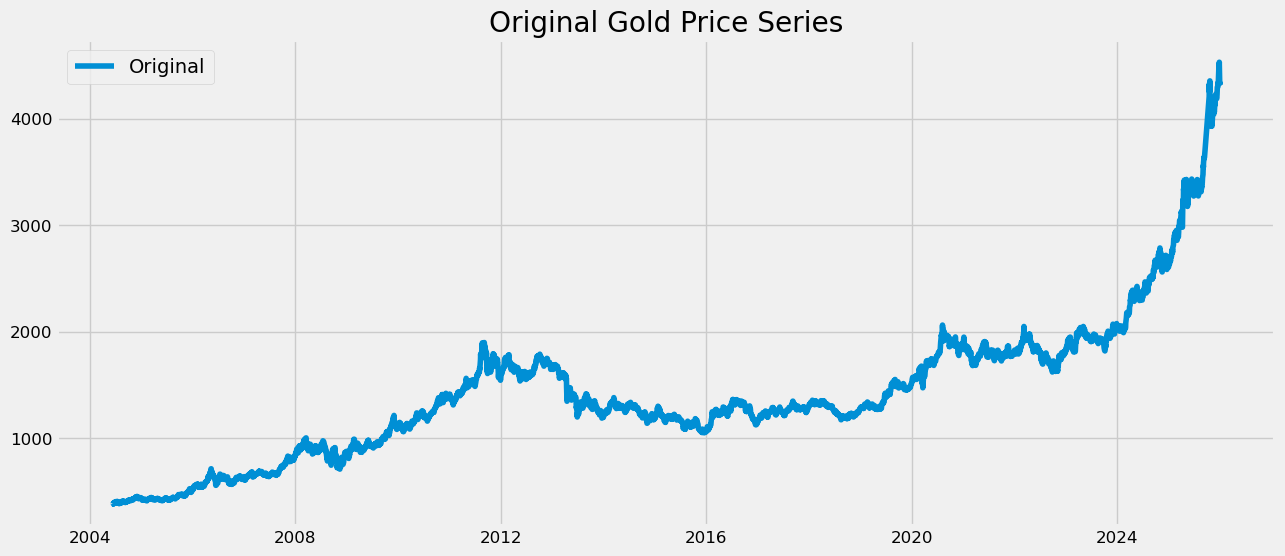

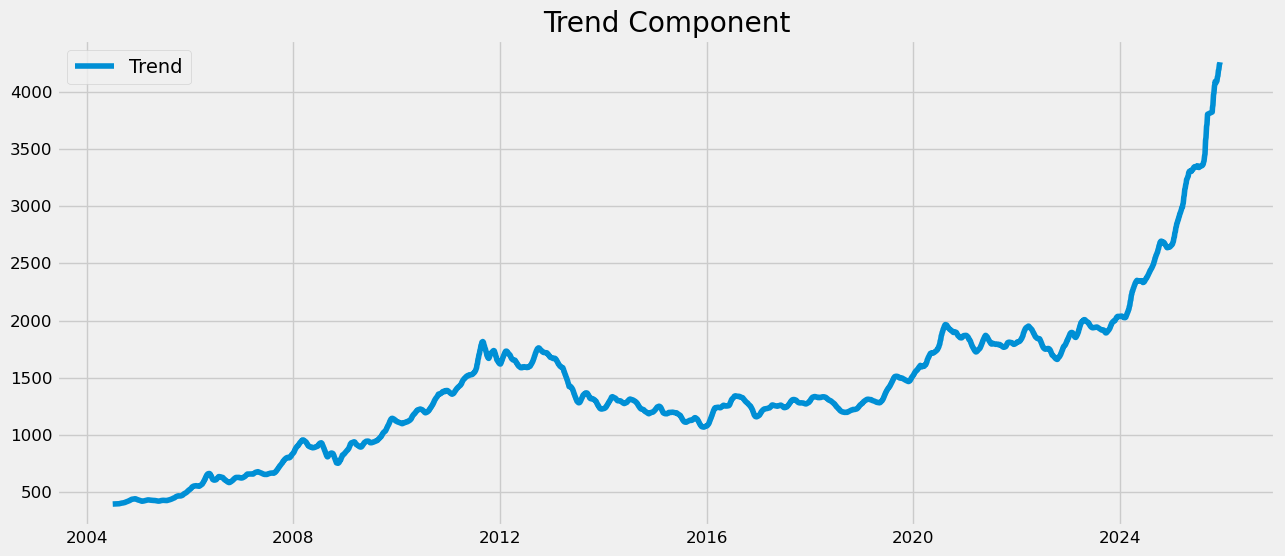

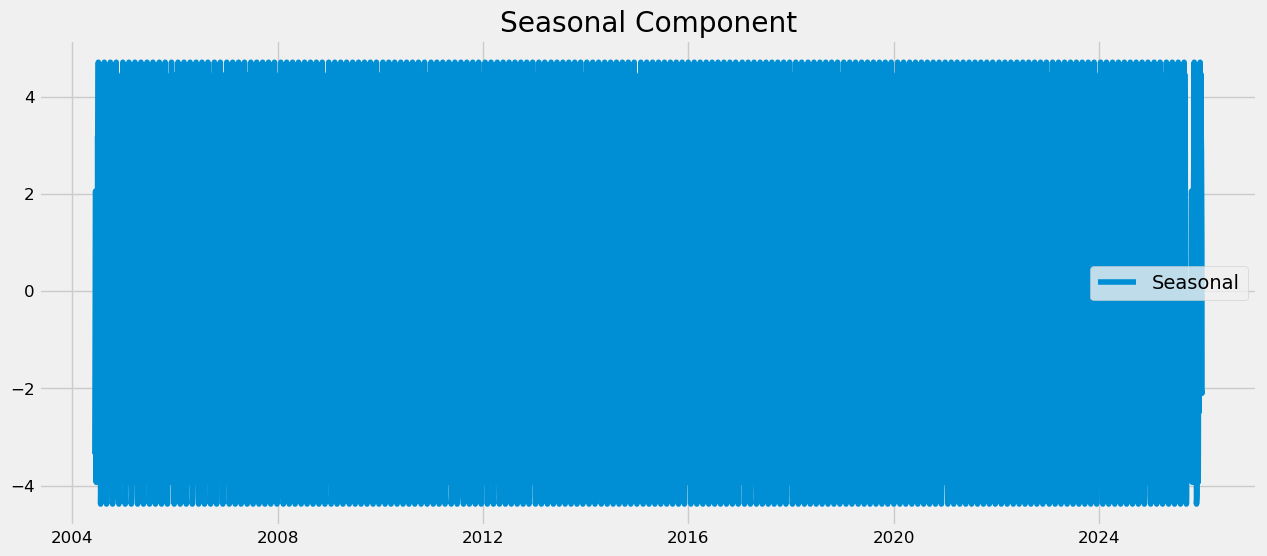

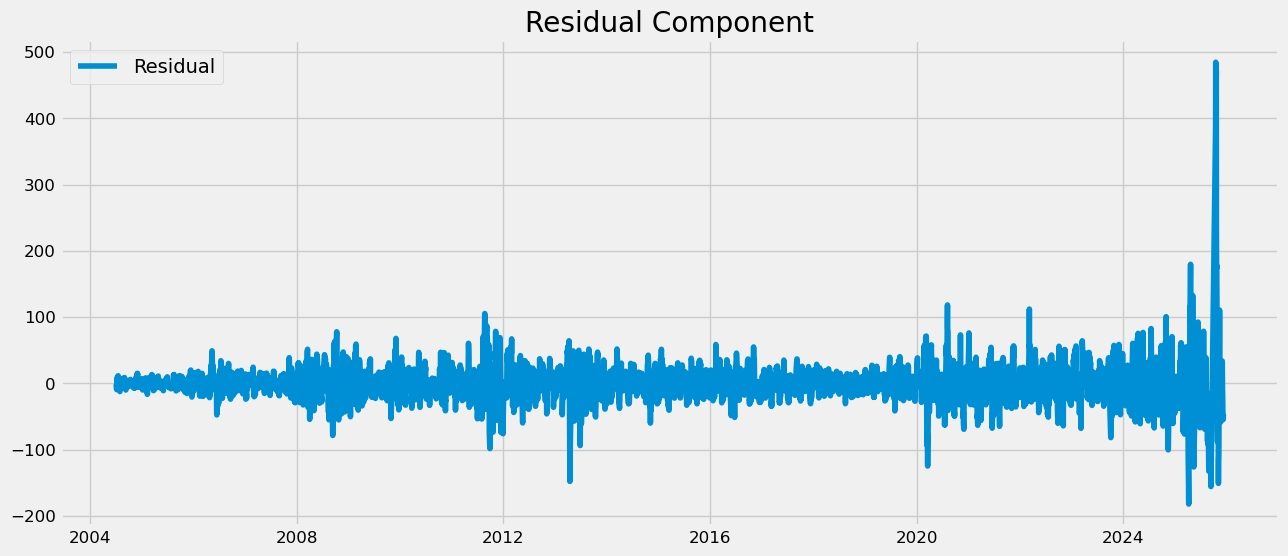

In [18]:
#perform seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(y,model='additive',period=30)
plt.figure(figsize=(14,6))
plt.plot(y, label='Original')
plt.title("Original Gold Price Series")
plt.legend(loc='best')
plt.show()
trend = decomposition.trend

plt.figure(figsize=(14,6))
plt.plot(trend, label='Trend')
plt.title("Trend Component")
plt.legend(loc='best')
plt.show()

seasonal = decomposition.seasonal

plt.figure(figsize=(14,6))
plt.plot(seasonal, label='Seasonal')
plt.title("Seasonal Component")
plt.legend(loc='best')
plt.show()
residual = decomposition.resid

plt.figure(figsize=(14,6))
plt.plot(residual, label='Residual')
plt.title("Residual Component")
plt.legend(loc='best')
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: 3.6733050510255163
p-value: 1.0
Critical Values:
1%: -3.431542773561835
5%: -2.8620670871931293
10%: -2.567050567388145


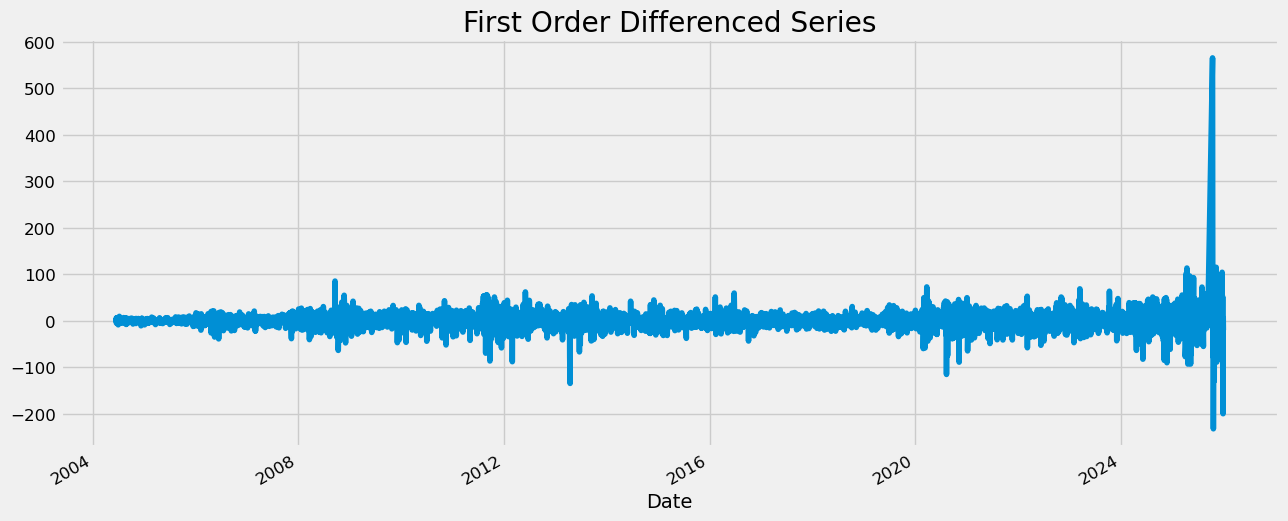

In [20]:
df_diff = df['Close'].diff().dropna()

plt.figure(figsize=(14,6))
df_diff.plot()
plt.title("First Order Differenced Series")
plt.show()

In [21]:
result_diff = adfuller(df_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -12.59621404570118
p-value: 1.7764944082533647e-23


In [22]:
adfuller(df_diff)

(np.float64(-12.59621404570118),
 np.float64(1.7764944082533647e-23),
 29,
 5485,
 {'1%': np.float64(-3.431542773561835),
  '5%': np.float64(-2.8620670871931293),
  '10%': np.float64(-2.567050567388145)},
 np.float64(47371.12345625152))

In [23]:
import itertools

p = q = range(0, 3)
d = [1]

pdq = list(itertools.product(p, d, q))

In [24]:
import statsmodels.api as sm

best_aic = float("inf")
best_param = None

for param in pdq:
    try:
        model = sm.tsa.ARIMA(df['Close'], order=param)
        results = model.fit()

        if results.aic < best_aic:
            best_aic = results.aic
            best_param = param

        print(param, results.aic)

    except:
        continue

print("\nBest ARIMA model:", best_param)
print("Best AIC:", best_aic)

(0, 1, 0) 47706.23539333619
(0, 1, 1) 47705.18616451207
(0, 1, 2) 47705.13098518376
(1, 1, 0) 47705.292757958305
(1, 1, 1) 47692.74652157296
(1, 1, 2) 47694.745736886194
(2, 1, 0) 47705.63542394778
(2, 1, 1) 47694.7457379455
(2, 1, 2) 47693.16263254368

Best ARIMA model: (1, 1, 1)
Best AIC: 47692.74652157296


In [25]:
model = sm.tsa.ARIMA(df['Close'], order=best_param)
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5516
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -23843.373
Date:                Fri, 20 Feb 2026   AIC                          47692.747
Time:                        18:57:01   BIC                          47712.592
Sample:                             0   HQIC                         47699.668
                               - 5516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8928      0.026    -34.026      0.000      -0.944      -0.841
ma.L1          0.9185      0.024     38.372      0.000       0.872       0.965
sigma2       333.2569      0.715    466.268      0.0

In [30]:
forecast = results.forecast(steps=60)

print("Next 7-Day Forecast:")
print(forecast)

Next 7-Day Forecast:
5516    4312.532268
5517    4317.735112
5518    4313.090151
5519    4317.237049
5520    4313.534808
5521    4316.840071
5522    4313.889220
5523    4316.523661
5524    4314.171702
5525    4316.271469
5526    4314.396853
5527    4316.070460
5528    4314.576308
5529    4315.910247
5530    4314.719342
5531    4315.782551
5532    4314.833346
5533    4315.680771
5534    4314.924212
5535    4315.599648
5536    4314.996637
5537    4315.534989
5538    4315.054363
5539    4315.483453
5540    4315.100373
5541    4315.442377
5542    4315.137044
5543    4315.409637
5544    4315.166274
5545    4315.383542
5546    4315.189571
5547    4315.362743
5548    4315.208139
5549    4315.346165
5550    4315.222939
5551    4315.332952
5552    4315.234736
5553    4315.322421
5554    4315.244138
5555    4315.314027
5556    4315.251632
5557    4315.307336
5558    4315.257605
5559    4315.302004
5560    4315.262366
5561    4315.297754
5562    4315.266160
5563    4315.294366
5564    4315.269184

In [32]:
# Create future date index
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=60,
    freq='D'
)

forecast.index = future_dates

In [33]:
feb_forecast = forecast['2026-02-01':'2026-02-28']

print(feb_forecast)

2026-02-01    4315.362743
2026-02-02    4315.208139
2026-02-03    4315.346165
2026-02-04    4315.222939
2026-02-05    4315.332952
2026-02-06    4315.234736
2026-02-07    4315.322421
2026-02-08    4315.244138
2026-02-09    4315.314027
2026-02-10    4315.251632
2026-02-11    4315.307336
2026-02-12    4315.257605
2026-02-13    4315.302004
2026-02-14    4315.262366
2026-02-15    4315.297754
2026-02-16    4315.266160
2026-02-17    4315.294366
2026-02-18    4315.269184
2026-02-19    4315.291666
2026-02-20    4315.271595
2026-02-21    4315.289514
2026-02-22    4315.273516
2026-02-23    4315.287798
2026-02-24    4315.275048
2026-02-25    4315.286431
2026-02-26    4315.276268
2026-02-27    4315.285341
2026-02-28    4315.277241
Freq: D, Name: predicted_mean, dtype: float64


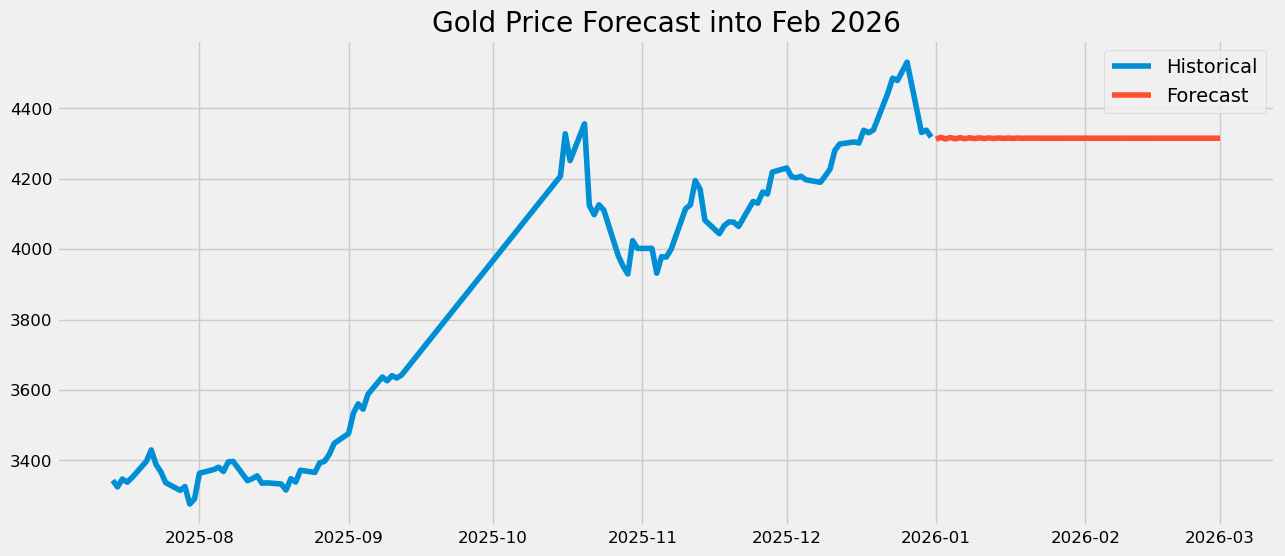

In [35]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'][-100:], label='Historical')
plt.plot(forecast, label='Forecast')

plt.title("Gold Price Forecast into Feb 2026")
plt.legend()
plt.show()

In [37]:
jan_end = forecast['2026-01-31']
feb_end = forecast['2026-02-28']

if feb_end > jan_end:
    print("Gold expected to increase in Feb 2026")
else:
    print("Gold expected to decrease in Feb 2026")

Gold expected to increase in Feb 2026


The ARIMA(1,1,1) model forecasts a mild upward trend in gold prices
for Feb 2026 based on historical price dynamics, indicating continued bullish momentum

In [38]:
forecast_results = results.get_forecast(steps=60)

forecast_mean = forecast_results.predicted_mean
forecast_ci = forecast_results.conf_int()

In [39]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=60,
    freq='D'
)

forecast_mean.index = future_dates
forecast_ci.index = future_dates

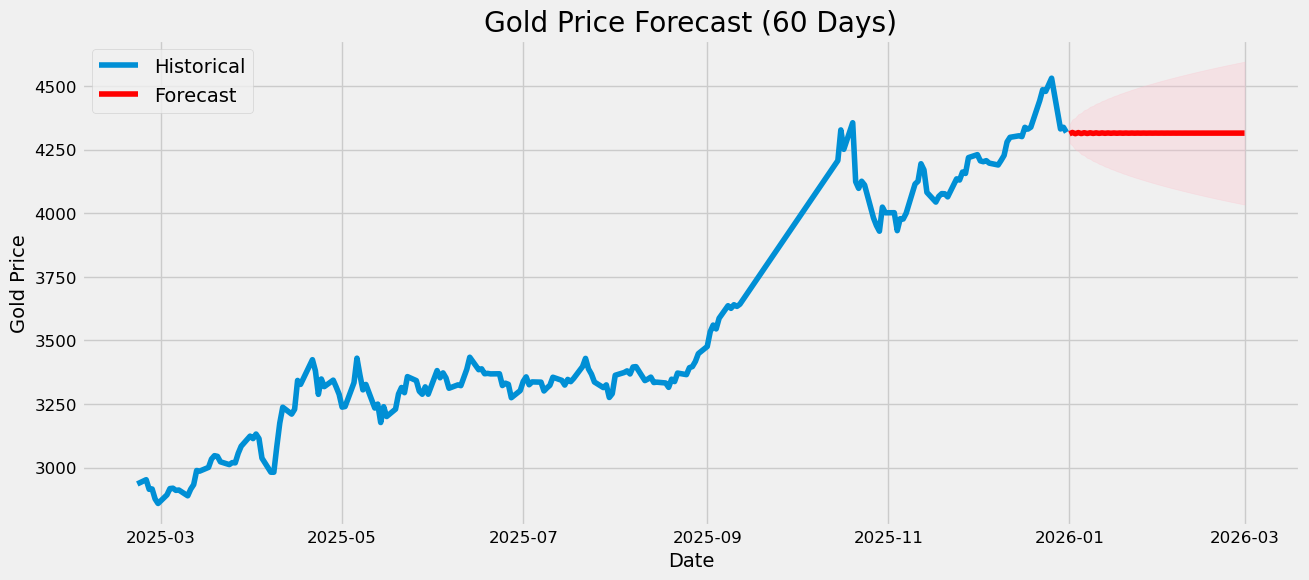

In [40]:
plt.figure(figsize=(14,6))

# Historical data
plt.plot(df['Close'][-200:], label='Historical')

# Forecast mean
plt.plot(forecast_mean, label='Forecast', color='red')

# Confidence interval
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='pink',
    alpha=0.3
)

plt.title("Gold Price Forecast (60 Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

The red line represents ARIMA forecasted gold prices, while the shaded region
indicates the 95% confidence interval reflecting prediction uncertainty

In [41]:
#Model evaluation
train = df['Close'][:'2024']
test = df['Close']['2025':]

In [42]:
model = sm.tsa.ARIMA(train, order=(1,1,1))
results = model.fit()

In [43]:
forecast_test = results.forecast(steps=len(test))

In [44]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast_test))

print("RMSE:", rmse)

RMSE: 922.0352018718436


The ARIMA model achieved an RMSE of ~922, which reflects moderate deviation in absolute price forecasting,
expected in financial time series due to volatility and macroeconomic shocks

In [45]:
actual_direction = (test.diff() > 0).astype(int)

In [46]:
predicted_direction = (forecast_test.diff() > 0).astype(int)

In [47]:
actual_direction = actual_direction[1:]
predicted_direction = predicted_direction[1:]

In [48]:
from sklearn.metrics import accuracy_score

direction_accuracy = accuracy_score(
    actual_direction,
    predicted_direction
)

print("Direction Accuracy:", direction_accuracy)

Direction Accuracy: 0.5659574468085107


Gold prices are influenced by macroeconomic variables such as inflation, interest rates, and currency strength. Since this model uses only historical price data, predictive power is limited. Incorporating external factors could improve accuracy